NAME: **Ibeh Chimchetam Christabel**  
TRACK: **OIBSIP ( Data Analytics)**  
TITLE: **Retail Sales Data (EDA)**  
DATASET SOURCE: **Kaggle**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading the dataset
df = pd.read_csv("C:/Users/Admin/OneDrive/Documents/My Data Sources/retail_sales_dataset.csv")

In [3]:
#initial inspection
print(f"Shape:{df.shape}\n")
print(f"Dtypes:\n{df.dtypes}\n")
print(f"Nulls:\n{df.isnull().sum()}\n")
print(f"Duplicates:\n{df.duplicated().sum()}\n")

Shape:(1000, 9)

Dtypes:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Nulls:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicates:
0



In [4]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
#Descriptive Statistics(Age)
print(f"Mean(Age): {df['Age'].mean():.2f}")
print(f"Median(Age): {df['Age'].median():.2f}")
print(f"Mode(Age):\n{df['Age'].mode()}")
print(f"Std Dev(Age): {df['Age'].std():.2f}")

Mean(Age): 41.39
Median(Age): 42.00
Mode(Age):
0    43
1    64
Name: Age, dtype: int64
Std Dev(Age): 13.68


In [6]:
#Descriptive Statistics(Quantity)
print(f"Mean(Quantity): {df['Quantity'].mean():.2f}")
print(f"Median(Quantity): {df['Quantity'].median():.2f}")
print(f"Mode(Quantity): {df['Quantity'].mode()}")
print(f"Std Dev(Quantity): {df['Quantity'].std():.2f}")

Mean(Quantity): 2.51
Median(Quantity): 3.00
Mode(Quantity): 0    4
Name: Quantity, dtype: int64
Std Dev(Quantity): 1.13


In [7]:
#Descriptive Statistics(Price per Unit)
print(f"Note: P/U = Price per Unit\n")
print(f"Mean(P/U): {df['Price per Unit'].mean():.2f}")
print(f"Median(P/U): {df['Price per Unit'].median():.2f}")
print(f"Mode(P/U): {df['Price per Unit'].mode()}")
print(f"Std Dev(P/U): {df['Price per Unit'].std():.2f}")


Note: P/U = Price per Unit

Mean(P/U): 179.89
Median(P/U): 50.00
Mode(P/U): 0    50
Name: Price per Unit, dtype: int64
Std Dev(P/U): 189.68


In [8]:
#Descriptive Statistics(Total Amount)
print(f"Mean(Total amount): {df['Total Amount'].mean():.2f}")
print(f"Median(Total amount): {df['Total Amount'].median():.2f}")
print(f"Mode(Total amount): {df['Total Amount'].mode()}")
print(f"Std Dev(Total amount): {df['Total Amount'].std():.2f}")

Mean(Total amount): 456.00
Median(Total amount): 135.00
Mode(Total amount): 0    50
Name: Total Amount, dtype: int64
Std Dev(Total amount): 560.00


In [25]:
#Time Series Analysis
#converting Date to TimeDate format
df['Date'] = pd.to_datetime(df['Date'], format = 'mixed', errors = 'coerce')

#creating monthly & quarterly groups
df['Month'] = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')

#data grouping
monthly_sales = df.groupby('Month')['Total Amount'].sum()
quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()


In [26]:
df.dtypes

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
Month                    period[M]
Quarter              period[Q-DEC]
Age Groups                category
Day                         object
dtype: object

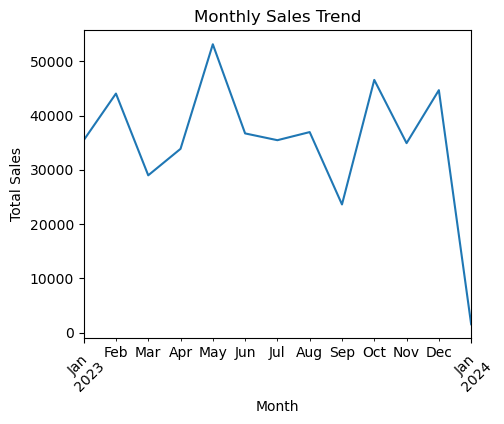

In [27]:
#Monthly Sales Trend Analysis
monthly_sales.plot(kind= 'line', figsize = (5,4))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

**Observation:** The Monthly Sales Trend Chart shows a highly volatile pattern throughout the year, having, May (~ 53,000), October (~ 46,000) and December (~ 44,000), as the peak months, and, September (~ 23,000), March (~ 29,000) as the months with the lowest sales.  
**Note:** Jan 2024's near zero dip represents incomplete data, not a collapse.

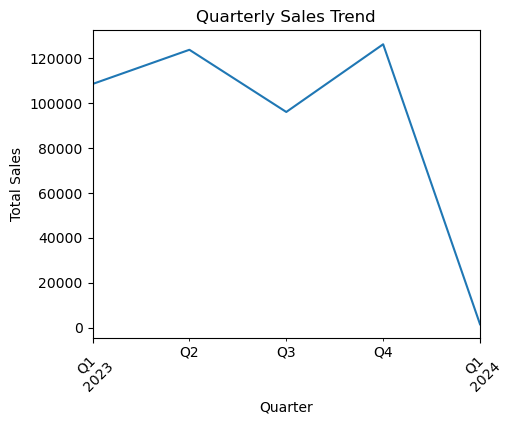

In [28]:
#Quarterly Sales Trend Analysis
quarterly_sales.plot(kind= 'line', figsize = (5,4))
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

**Observation:** The Quarterly Sales Trend Chart shows a dip in sales the third quarter before a spike to the highest sales value in the fourth quarter which suggests a seasonal period where customers were saving up to make seasonal purchases (e.g. holiday shopping,restocking for the new year, etc). The sharp drop in Q1 2024 does not depict true sales, rather, it highlights that the dataset only contains a partial period for that quarter.

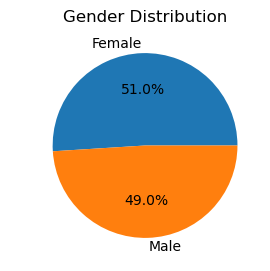

In [29]:
#Customer Demographics
#Gender Distribution
df.groupby('Gender')['Customer ID'].count().plot(kind= 'pie', autopct= '%1.1f%%', figsize = (4,3))
plt.title('Gender Distribution')
plt.ylabel(' ')
plt.show()

**Observation:** The Gender distribution chart shows an almost equal distribution between both genders with a difference of just 2%.

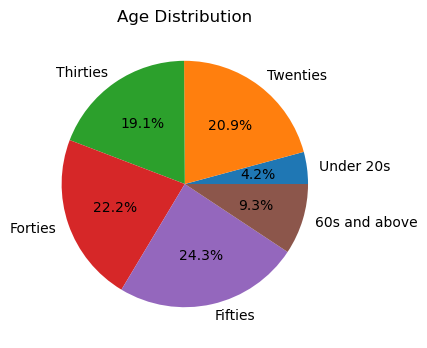

In [30]:
#Customer Demographics
df['Age Groups'] = pd.cut(df['Age'], 
                               bins=[0, 19, 29, 39, 49, 60, float('inf')], 
                               labels=['Under 20s', 'Twenties', 'Thirties', 'Forties', 'Fifties','60s and above'])
#Age Distribution chart
df.groupby('Age Groups', observed=True)['Customer ID'].count().plot(kind='pie', autopct='%1.1f%%', figsize = (5,4))
plt.title('Age Distribution')
plt.ylabel(' ')
plt.show()


**Observation:** The business has an almost even distribution of customers between various age groups with exception of the dependant age groups (under 20s and above 60s) which collectively make up only 13.5% of the business's total population.

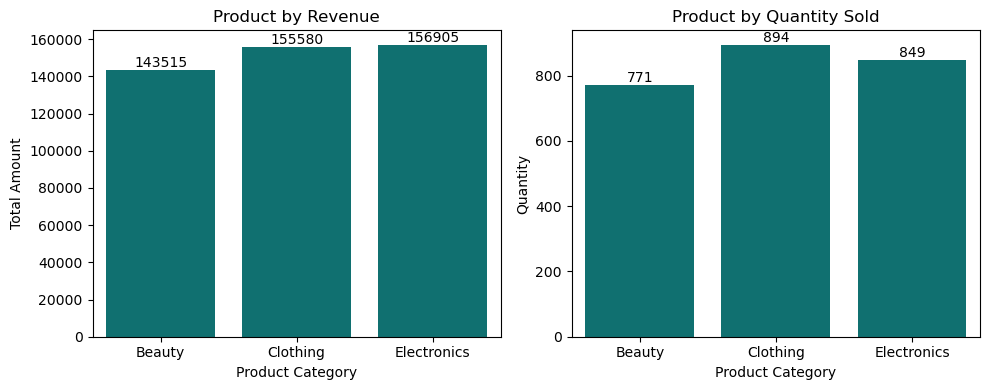

In [31]:
#Product Analysis
#Data Grouping
revenue = df.groupby('Product Category')['Total Amount'].sum().reset_index()
quantity = df.groupby('Product Category')['Quantity'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Chart 1: Revenue
sns.barplot(data=revenue, x='Product Category', y='Total Amount', color='teal', ax=axes[0])
axes[0].set_title('Product by Revenue')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Total Amount')
axes[0].bar_label(axes[0].containers[0], fmt='%.0f')

# Chart 2: Quantity
sns.barplot(data=quantity, x='Product Category', y='Quantity', color='teal', ax=axes[1])
axes[1].set_title('Product by Quantity Sold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Quantity')
axes[1].bar_label(axes[1].containers[0], fmt='%.0f')

plt.tight_layout()
plt.show()

**Observation:** The Product analysis charts show that electronics generates the highest revenue despite not having the highest product by Quantity sold, and beauty products generates lowest revenue and is the lowest product by quantity sold.

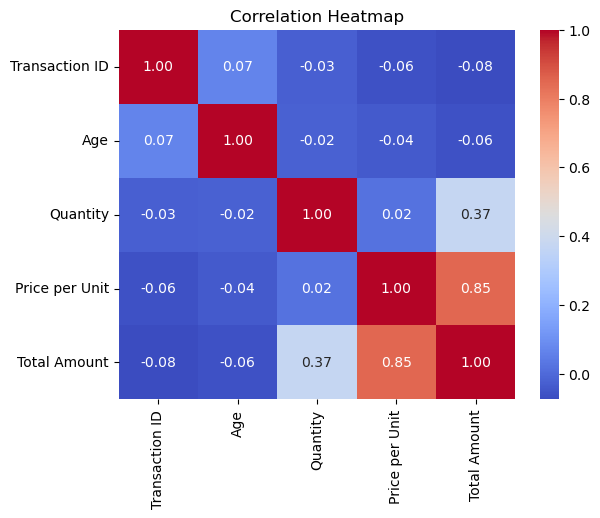

In [32]:
#Correlation Analysis
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap= 'coolwarm', fmt= '.2f')
plt.title('Correlation Heatmap')
plt.show()

**Observation:** The correlation Heatmap shows; a very strong positive correlation between Price Per Unit and Total Amount (0.85), a moderate positive correlation between Quantity and Total Amount (0.37), and a very low correlation between Quantity and Price per unit (0.02).  
This suggests that transaction value is driven more by what is being bought than how much of it is bought, and higher item prices do not reduce purchase volume.  

In [33]:
#day of week analysis
df['Day'] = df['Date'].dt.day_name()

#data grouping
Daily_sales = df.groupby('Day')['Total Amount'].mean()
day_order = ['Sunday','Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
Daily_sales = Daily_sales.reindex(day_order)

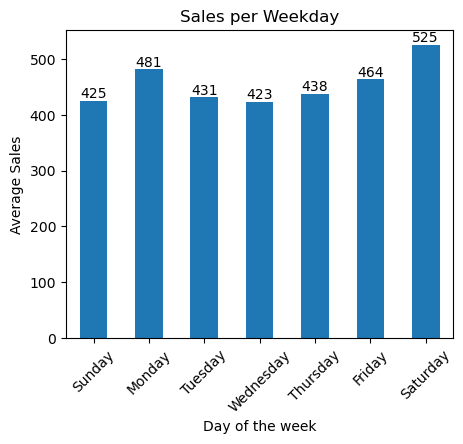

In [34]:
ax = Daily_sales.plot(kind= 'bar', figsize = (5,4))
plt.title('Sales per Weekday')
plt.xlabel('Day of the week')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.bar_label(ax.containers[0], fmt='%.0f')
plt.show()

**Observation:** The sales per weekday chart shows that sales consistently drop till the lowest levels during mid-week days, before gradually picking up towards weekends. Saturday generates the highest average sales, followed by Monday, and Wednesday generates the lowest average sales.

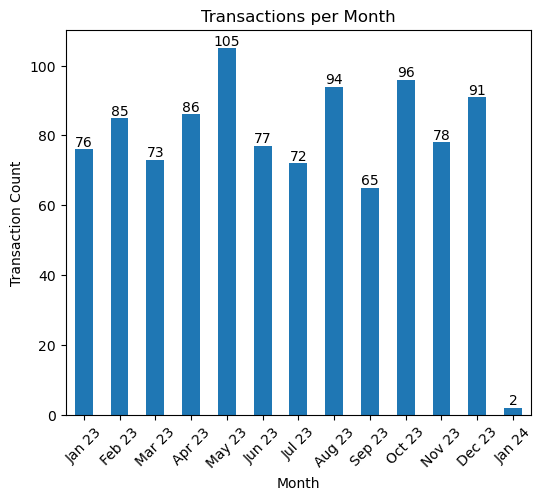

In [36]:
#Transactions per Month Analysis
Transactions_per_month = df.groupby('Month')['Transaction ID'].count()
Transactions_per_month.index = Transactions_per_month.index.strftime('%b %y')
ax = Transactions_per_month.plot(kind= 'bar', figsize = (6,5))
plt.title('Transactions per Month')
plt.xlabel('Month')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45)
plt.bar_label(ax.containers[0], fmt='%.0f')
plt.show()

**Observation:** The Transactions per Month chart shows a relatively stable transaction volume, ranging *65 and 105* transactions monthly. April has the highest count *(105)*, while September has the lowest *(65)*. The suggests that the Septemer revenue dip noticed in the *Monthly Sales Trend* chart was mainly driven by lower transactions that month.  
The near-zero count in January 2024 *(2 transactions)* confirms the month's/quarter's data is incomplete.

**CONCLUSION**  
**Recommendations**  
1. Since transaction value is driven highly by item price rather than purchase quantity, and pricing has very low effect on quantity per transaction, the business should prioritize strategies that increase average item value, such as,promoting higher-margin product(creating a featured section), and bundling (creating a package of complementary items at a combined price),rather than volume-based promotions("buy more, save more")
2.  Since average sales are higher during Saturdays and Mondays, the business should ensure that products are stocked sufficiently to meet demand and consider a promotional mid-week discount to improve mid-week sales.
3.  Since customers are almost evenly split by gender *(51% female, 49% male)* and age with majority of the customers falling within the *forties and fifties* age bracket, marketing should be built around a general-audience approach, with slightly heavier emphasis on messages that resonates with with adults in their 40s and 50s.
4.  Considering September's dip is driven by a decline in transactions *(65, the year's lowest)*, the business should carry out an investigation into operational or seasonal factors, and consider running a September-targeted campaign to counter slow down.